## Modelling - BactHeCom
This scripts contains the code for computing and evaluating different model algorithms to predict mortality at 30 days

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

In [2]:
DATA_DIR = "../data"
RESULTS_DIR = "../results"

os.makedirs(f"{RESULTS_DIR}/model/selection_model", exist_ok=True)

### Load data

In [3]:
### Load merged df
df = pd.read_csv(f"{DATA_DIR}/preprocessed_df.csv")
df.head()

,record_id,sexo,fecha_ingreso,fecha_alta,foco_controlable,IRAs_nosocomial,mortalidad,fecha_mortalidad,dias_hemocultivo_mortalidad,mortalidad_30_dias,...,cateter_venoso,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit,antimicrobiano_list,cmi_list,interpretacion_list,antimicrobiano_family_list
0,1,0,2021-08-24,2021-09-09,NaN,1,1,2021-09-09,9.0,1,...,0,0,1,0,0,0,"['Cefazolina', 'Trimetoprim', 'Ertapenem', 'Ce...","['>16 mg/L', '>4 mg/L', '>1 mg/L', '>8 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'I', ...","['Cefalosporin', 'TMP_SMX', 'Carbapenem', 'Cef..."
1,2,1,2023-06-18,2023-07-13,NaN,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Cefuroxima', ...","['>4/76 mg/L', '<=8 mg/L', '0.5 mg/L', '<=0.5 ...","['R', 'I', 'I', 'S', 'S', 'S', 'S', 'S', 'S', ...","['TMP_SMX', 'Cefalosporin', 'Quinolone', 'Quin..."
2,3,0,2022-02-11,2022-04-06,1.0,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Ampicilina', ...","['>4/76 mg/L', '>8 mg/L', '>4 mg/L', '>1 mg/L'...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Penicillin', 'Aminoglycoside', 'Q..."
3,4,0,2021-05-15,2021-07-28,NaN,1,0,NaN,NaN,0,...,0,0,1,0,0,0,"['Trimetoprim', 'Levofloxacino', 'Ertapenem', ...","['>4 mg/L', '>1 mg/L', '>1 mg/L', '>16 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Quinolone', 'Carbapenem', 'Cefalo..."
4,5,1,2021-07-04,2022-01-04,0.0,1,0,NaN,NaN,0,...,0,0,0,0,0,0,"['Aztreonam', 'Ciprofloxacino', 'Ceftazidima',...","['<=1 mg/L', '>1 mg/L', '<=1 mg/L', '>8 mg/L',...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['Monobactam', 'Quinolone', 'Cefalosporin', 'C..."


### Mortality imbalance

In [4]:
print(f"Mortality at 30 days: {df['mortalidad_30_dias'].sum()/df.shape[0]*100:.2f}% of total records")  # target prevalence

Mortality at 30 days: 18.36% of total records


### Target and non-target columns

In [5]:
TARGET = "mortalidad_30_dias"

NONTARGETCOLS = ["record_id", "episode_id", "fecha_ingreso", "fecha_alta", "fecha_mortalidad", "mortalidad","dias_hemocultivo_mortalidad",
             "microorganismos_dict", "fechas_dict", "especimen_dict", "duracion_UCI","uci_por_el_episodio", "antimicrobiano_list", "cmi_list",
             "interpretacion_list", "antimicrobiano_family_list"]

df_ = df.drop(columns=NONTARGETCOLS) 

### Missing values heatmap

In [6]:
NA_THRESHOLD = 5

In [7]:
na_tbl = df_.isna().sum().sort_values(ascending=False)
missing_vars = []

for col in na_tbl[na_tbl > 0].index:
    pct = na_tbl[col] / len(df_) * 100
    if pct > NA_THRESHOLD:
        missing_vars.append(col)
        print(f"{col}: {na_tbl[col]} missing values --> {pct:.2f}% NaN")

taquipnea: 3845 missing values --> 97.24% NaN
frecuencia_respiratoria: 3845 missing values --> 97.24% NaN
hipotermia_hipertermia: 3592 missing values --> 90.84% NaN
taquicardia: 3384 missing values --> 85.58% NaN
hipoxemia: 3381 missing values --> 85.51% NaN
barthel_inf_90: 3042 missing values --> 76.93% NaN
foco_controlable: 2365 missing values --> 59.81% NaN
disuria: 1489 missing values --> 37.66% NaN
dolor_abdominal: 1479 missing values --> 37.41% NaN
vomitos: 1479 missing values --> 37.41% NaN
fiebre: 1479 missing values --> 37.41% NaN
tos: 1479 missing values --> 37.41% NaN
dificultad_respirar: 1479 missing values --> 37.41% NaN
lesiones_piel: 1479 missing values --> 37.41% NaN
diarrea: 1479 missing values --> 37.41% NaN
tenesmo_ano_recto: 1479 missing values --> 37.41% NaN
dolor_fosa_renal: 1479 missing values --> 37.41% NaN
nauseas: 1479 missing values --> 37.41% NaN
tenesmo_vejiga: 1479 missing values --> 37.41% NaN
cefalea: 1479 missing values --> 37.41% NaN
dolores_articulare

In [8]:
# drop variables with too many missing values
df_ = df_.drop(columns=missing_vars)
print(f"Dropped {len(missing_vars)} variables with more than {NA_THRESHOLD}% missing values.")

Dropped 25 variables with more than 5% missing values.


In [9]:
# df dimensionality after dropping columns
print(f"Dataframe shape after dropping columns: {df_.shape}")

Dataframe shape after dropping columns: (3954, 106)


## Data Preprocessing

In [10]:
# Prepare data
X = df_.drop(columns=[TARGET])
y = df_[TARGET]

### Split data into train and tests sets
- Train / Validation: **70%** (80% train, 20% validation)
- Test: **30%**

In [11]:
# Split train ans test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99, stratify=y) # statify to preserve target distribution

### Models
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Adaboost
- SVC

In [12]:
models = {
    "Logistic_Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]),
    "Random_Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        auto_class_weights="Balanced",
        verbose=0,
        random_state=42,
        allow_writing_files=False 
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),   # SVC needs scaled features
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

### Train and predict models

In [13]:
results = {}
y_pred_probs = {}

for name, model in models.items():
    # fit model 
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results[name] = {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }   
    y_pred_probs[name] = y_prob

results_df = pd.DataFrame(results)
results_df.to_csv(f"{RESULTS_DIR}/model/selection_model/model_stats.csv")

print(results_df)

         Logistic_Regression  Random_Forest   XGBoost  LightGBM  CatBoost  \
ROC-AUC             0.744154       0.768981  0.735616  0.739893  0.744660   
PR-AUC              0.388078       0.487738  0.483163  0.479661  0.478172   

         AdaBoost       SVC  
ROC-AUC  0.667140  0.747905  
PR-AUC   0.285865  0.424829  


### Plot ROC and PR curves

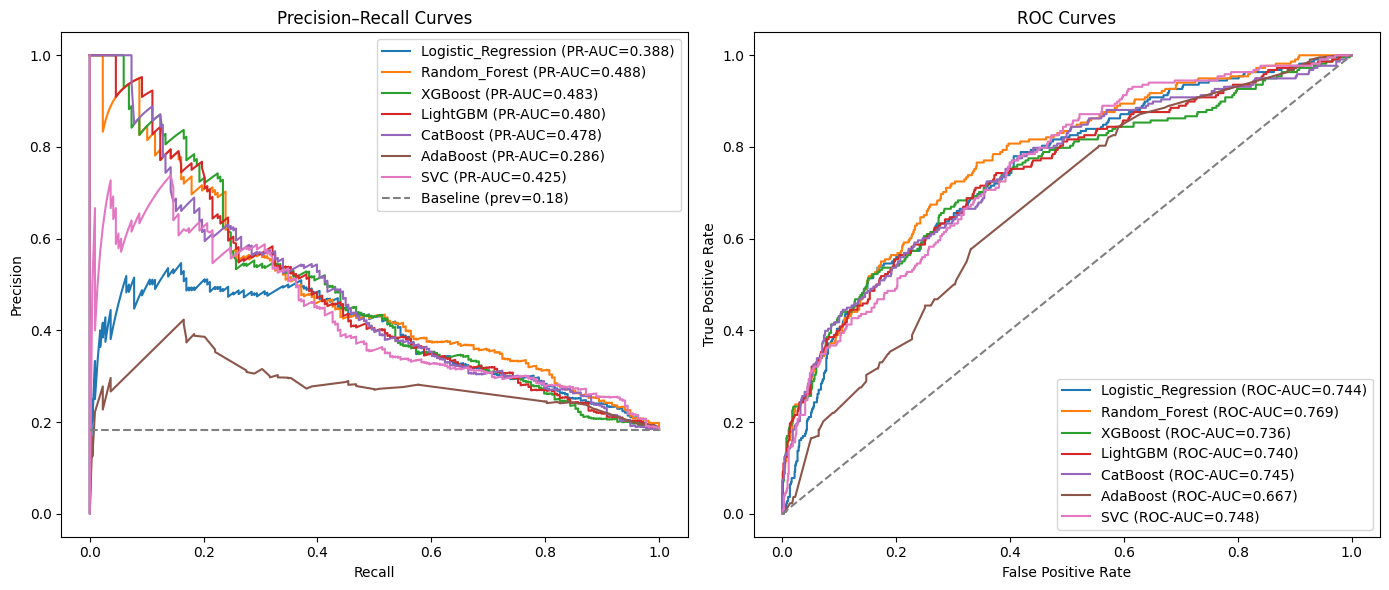

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --------------------
# Precision–Recall
# --------------------
for name, y_prob in y_pred_probs.items():
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    ax[0].plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={results[name]['PR-AUC']:.3f})"
    )

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("Precision–Recall Curves")
ax[0].legend()

# --------------------
# ROC
# --------------------
for name, y_prob in y_pred_probs.items():
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

    ax[1].plot(
        fpr,
        tpr,
        label=f"{name} (ROC-AUC={results[name]['ROC-AUC']:.3f})"
    )

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curves")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/selection_model/pr_roc_models_curves.png")
plt.show()


### Selected models for optimization:
- **Random Forest** - RandomSearch
- **LightGBM** - Optuna
- **XGBoost** - Optuna